In [7]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [8]:

import os                       
import numpy as np              
import pandas as pd             
import seaborn as sns           
import torch                  
import matplotlib.pyplot as plt
import torch.nn as nn           
from torch.utils.data import DataLoader 
from PIL import Image           
import torch.nn.functional as F 
import torchvision.transforms as transforms   
from torchvision.utils import make_grid       
from torchvision.datasets import ImageFolder 
from torchsummary import summary              
import tensorflow as ts 
from  tensorflow import keras
import itertools
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score, accuracy_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [ ]:

dataset = "C:/Users/princ/OneDrive/Desktop/images"
train_data = f"{dataset}/train"
valid_data = f"{dataset}/valid"
test_data = f"{dataset}/test"

In [10]:
diseases=os.listdir(train_data)
print(diseases)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy']


In [11]:
print("Number of classes : ",len(diseases))

Number of classes :  4


In [12]:
nums_train={}
nums_valid={}
for disease in diseases:
    nums_train[disease]=len(os.listdir(train_data+'/'+disease))
    nums_valid[disease]=len(os.listdir(valid_data+'/'+disease))
image_class_count_train=pd.DataFrame(nums_train.values(),index=nums_train.keys(),columns=['No. of images'])
print('Training data images count per class : ',)
print(image_class_count_train)

Training data images count per class : 
                          No. of images
Apple___Apple_scab                  100
Apple___Black_rot                   100
Apple___Cedar_apple_rust            100
Apple___healthy                     100


In [13]:

image_class_count_valid=pd.DataFrame(nums_valid.values(),index=nums_valid.keys(),columns=['No. of images'])
print('Validation data images count per class : ',)
print(image_class_count_valid)

Validation data images count per class : 
                          No. of images
Apple___Apple_scab                  100
Apple___Black_rot                   100
Apple___Cedar_apple_rust            100
Apple___healthy                     100


<Axes: title={'center': 'Training data images count per class'}, xlabel='Number of images', ylabel='Classes'>

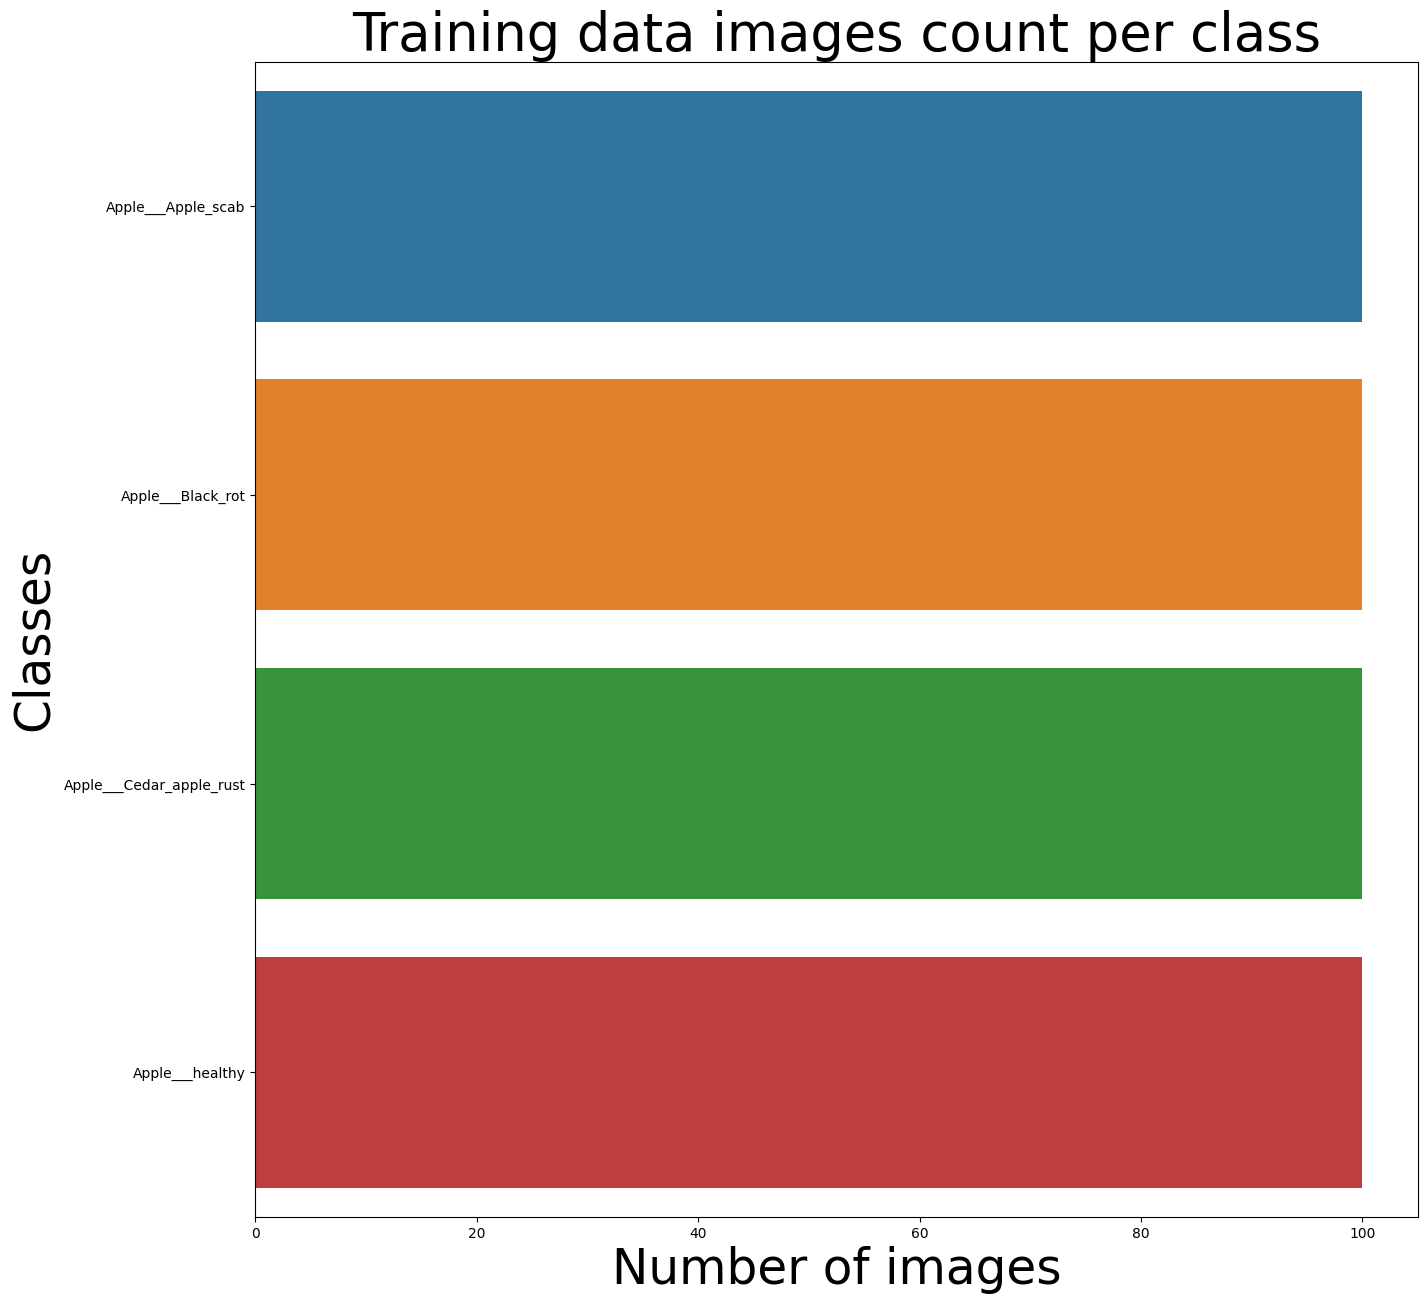

In [14]:
plt.figure(figsize=(15,15))
plt.title("Training data images count per class",fontsize=38)
plt.xlabel('Number of images', fontsize=35)
plt.ylabel('Classes', fontsize=35)

keys=list(nums_train.keys())
vals=list(nums_train.values())
sns.barplot(y=keys,x=vals)

<Axes: title={'center': 'Validation data images count per class'}, xlabel='Number of images', ylabel='Classes'>

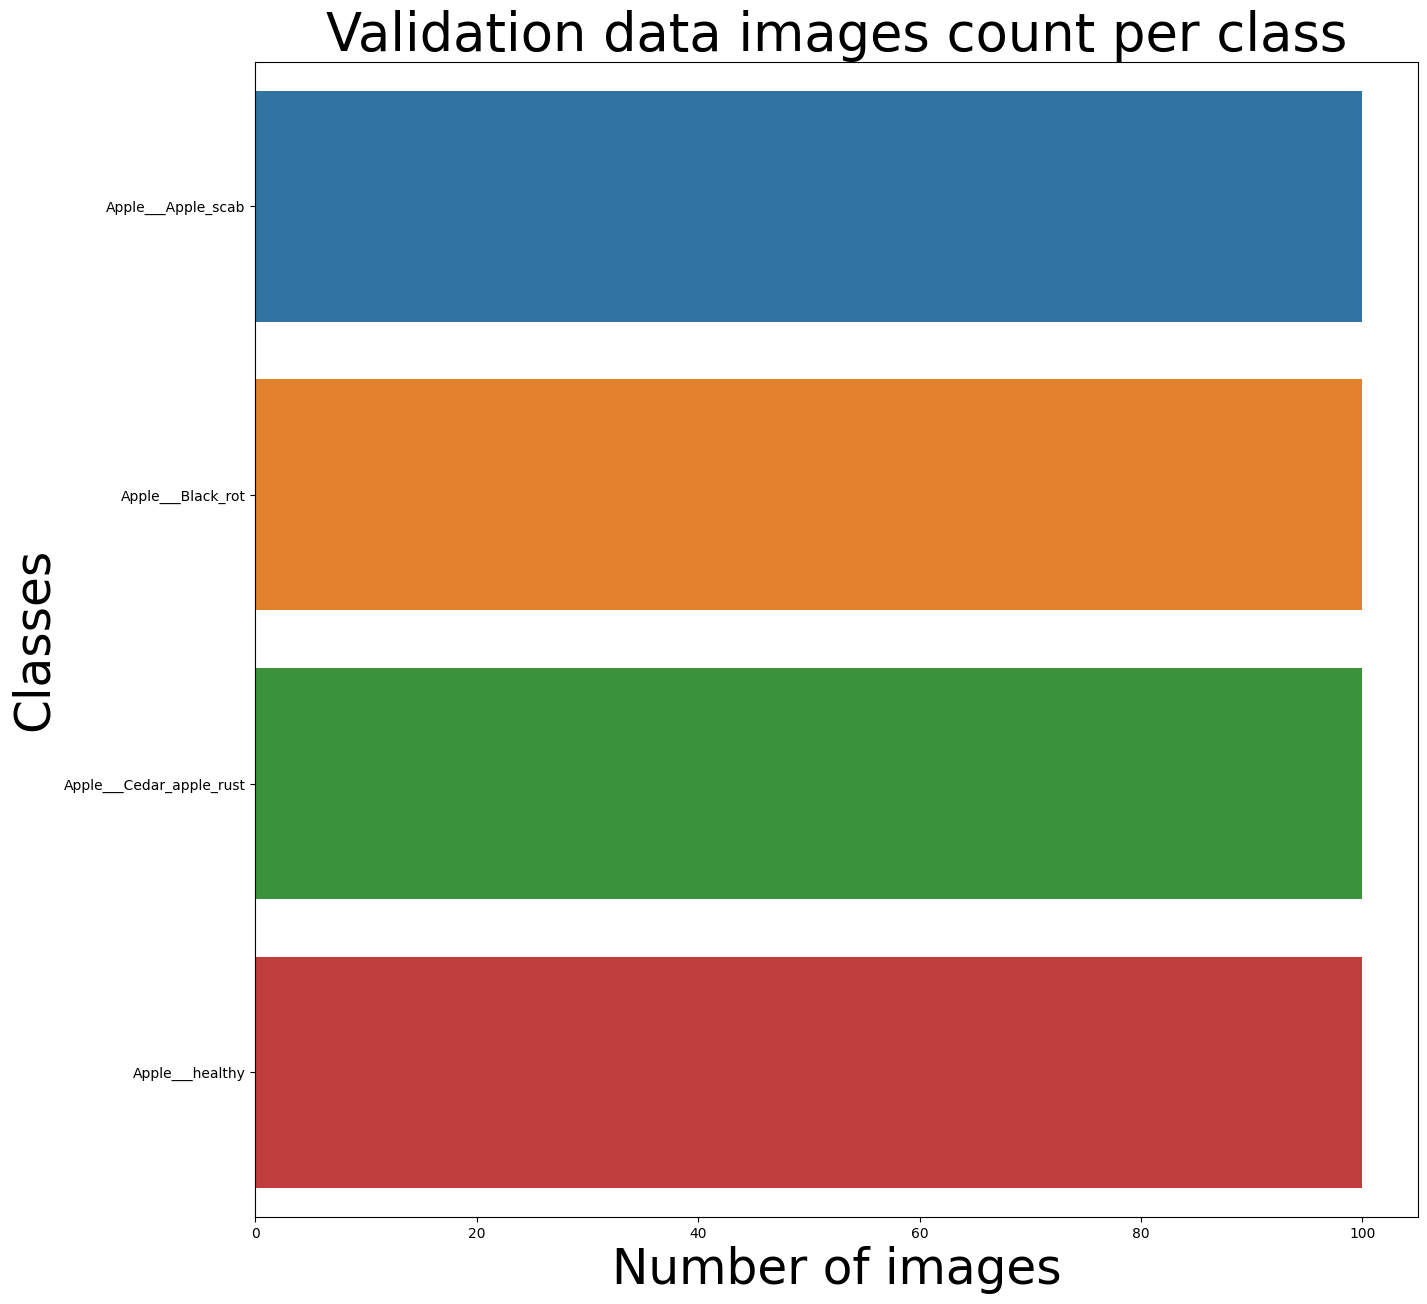

In [15]:
plt.figure(figsize=(15,15))
plt.title("Validation data images count per class",fontsize=38)
plt.xlabel('Number of images', fontsize=35)
plt.ylabel('Classes', fontsize=35)

keys=list(nums_valid.keys())
vals=list(nums_valid.values())
sns.barplot(y=keys,x=vals)

In [16]:
total_train=0
for value in nums_train.values():
    total_train+=value
print("Total number of images for training : ", total_train)

Total number of images for training :  400


In [17]:
total_valid=0
for value in nums_valid.values():
    total_valid+=value
print("Total number of images for validation : ", total_valid)

Total number of images for validation :  400


In [18]:
plants_unique=[]
diseases_unique=[]
for i in diseases:
    if(i.split('__'))[0] not in plants_unique:
        plants_unique.append(i.split('__')[0])
    if(i.split('___'))[1] != 'healthy':
        diseases_unique.append(i.split('___')[1])

In [19]:
print('Plants : ', plants_unique)
print('-'*100)
print('Number of plants : ', len(plants_unique))

Plants :  ['Apple']
----------------------------------------------------------------------------------------------------
Number of plants :  1


In [20]:

print('Diseases : ', diseases_unique)
print('-'*100)
print('Number of diseases : ', len(diseases_unique))

Diseases :  ['Apple_scab', 'Black_rot', 'Cedar_apple_rust']
----------------------------------------------------------------------------------------------------
Number of diseases :  3


In [21]:

rescale=keras.layers.Rescaling(scale=1.0/255)

In [22]:

training_data =keras.utils.image_dataset_from_directory(train_data , image_size=(256, 256))
validation_data = keras.utils.image_dataset_from_directory(valid_data, image_size=(256, 256))

Found 400 files belonging to 4 classes.
Found 400 files belonging to 4 classes.


In [23]:

train_gen = training_data.map(lambda image,label:(rescale(image),label))
valid_gen  = validation_data.map(lambda image,label:(rescale(image),label))

In [24]:
model = Sequential()


model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())


model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(38, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 128)      0

In [25]:
history = model.fit_generator(train_gen, validation_data=valid_gen, epochs = 25)

Epoch 1/25
13/13 [==============================] - 45s 3s/step - loss: 3.0237 - accuracy: 0.2750 - val_loss: 1.0865 - val_accuracy: 0.5000
Epoch 2/25
13/13 [==============================] - 31s 2s/step - loss: 1.1717 - accuracy: 0.5675 - val_loss: 0.5509 - val_accuracy: 0.8100
Epoch 3/25
13/13 [==============================] - 30s 2s/step - loss: 0.5561 - accuracy: 0.7850 - val_loss: 0.3204 - val_accuracy: 0.9025
Epoch 4/25
13/13 [==============================] - 29s 2s/step - loss: 0.4592 - accuracy: 0.8325 - val_loss: 0.3016 - val_accuracy: 0.9025
Epoch 5/25
13/13 [==============================] - 29s 2s/step - loss: 0.3521 - accuracy: 0.8550 - val_loss: 0.4055 - val_accuracy: 0.8525
Epoch 6/25
13/13 [==============================] - 30s 2s/step - loss: 0.3923 - accuracy: 0.8625 - val_loss: 0.1881 - val_accuracy: 0.9325
Epoch 7/25
13/13 [==============================] - 29s 2s/step - loss: 0.2187 - accuracy: 0.9125 - val_loss: 0.1876 - val_accuracy: 0.9450
Epoch 8/25
13/13 [==

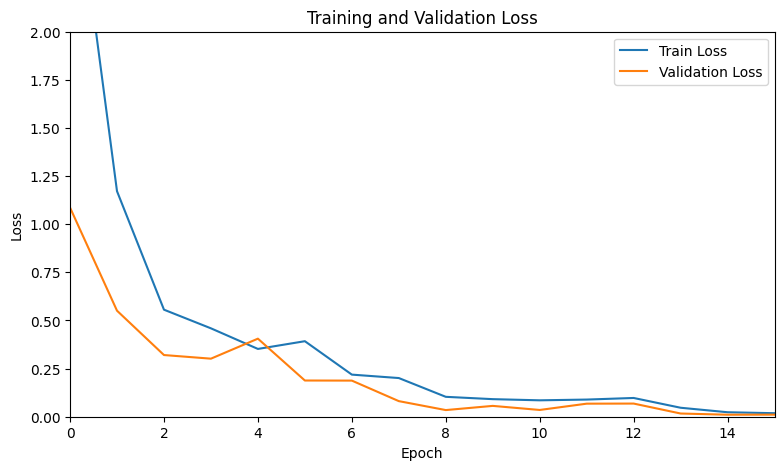

In [26]:

plt.figure(figsize = (20,5))
plt.subplot(1,2,1)
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(history.history['loss'],label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlim(0, 15)
plt.ylim(0.0,2.0)
plt.legend()

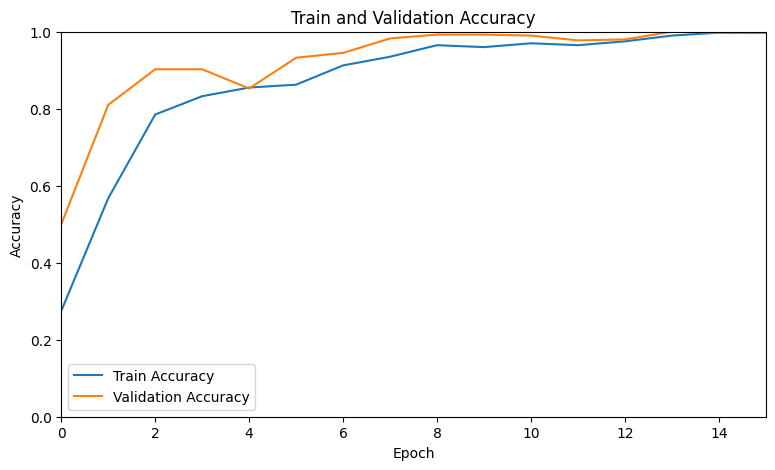

In [27]:

plt.figure(figsize = (20,5))
plt.subplot(1,2,1)
plt.title("Train and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlim(0, 15)
plt.ylim(0, 1.0)
plt.legend()

In [28]:

labels = []
predictions = []
for x,y in valid_gen:
    labels.append(list(y.numpy()))
    predictions.append(ts.argmax(model.predict(x),1).numpy())

1/1 [==============================] - 0s 236ms/step


In [29]:

predictions = list(itertools.chain.from_iterable(predictions))
labels = list(itertools.chain.from_iterable(labels))

In [30]:

print("Train Accuracy  : {:.2f} %".format(history.history['accuracy'][-1]*100))
print("Test Accuracy   : {:.2f} %".format(accuracy_score(labels, predictions) * 100))
print("Precision Score : {:.2f} %".format(precision_score(labels, predictions, average='micro') * 100))
print("Recall Score    : {:.2f} %".format(recall_score(labels, predictions, average='micro') * 100))

Train Accuracy  : 99.00 %
Test Accuracy   : 99.75 %
Precision Score : 99.75 %
Recall Score    : 99.75 %


<Figure size 2000x500 with 0 Axes>

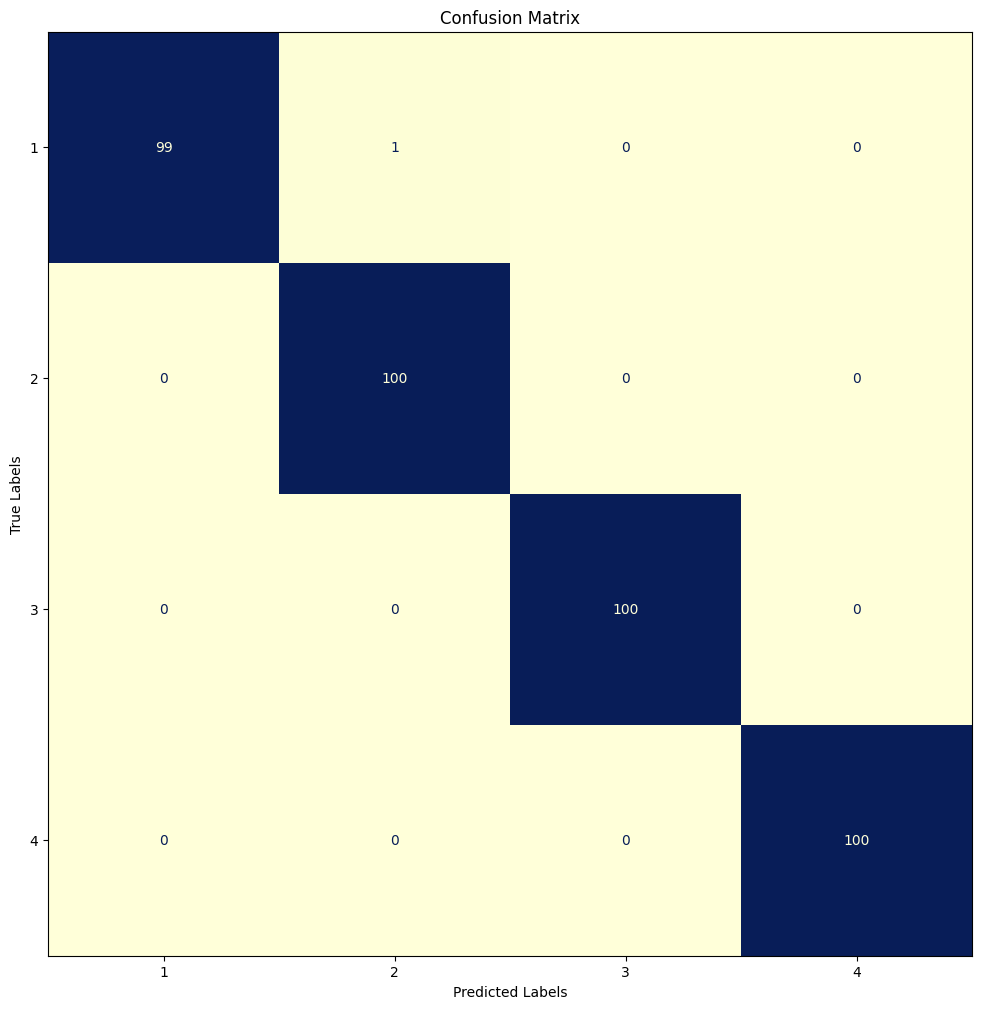

In [33]:

plt.figure(figsize= (20,5))
cm = confusion_matrix(labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1,5)))
fig, ax = plt.subplots(figsize=(12,12))
disp.plot(ax=ax,colorbar= False,cmap = 'YlGnBu')
plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

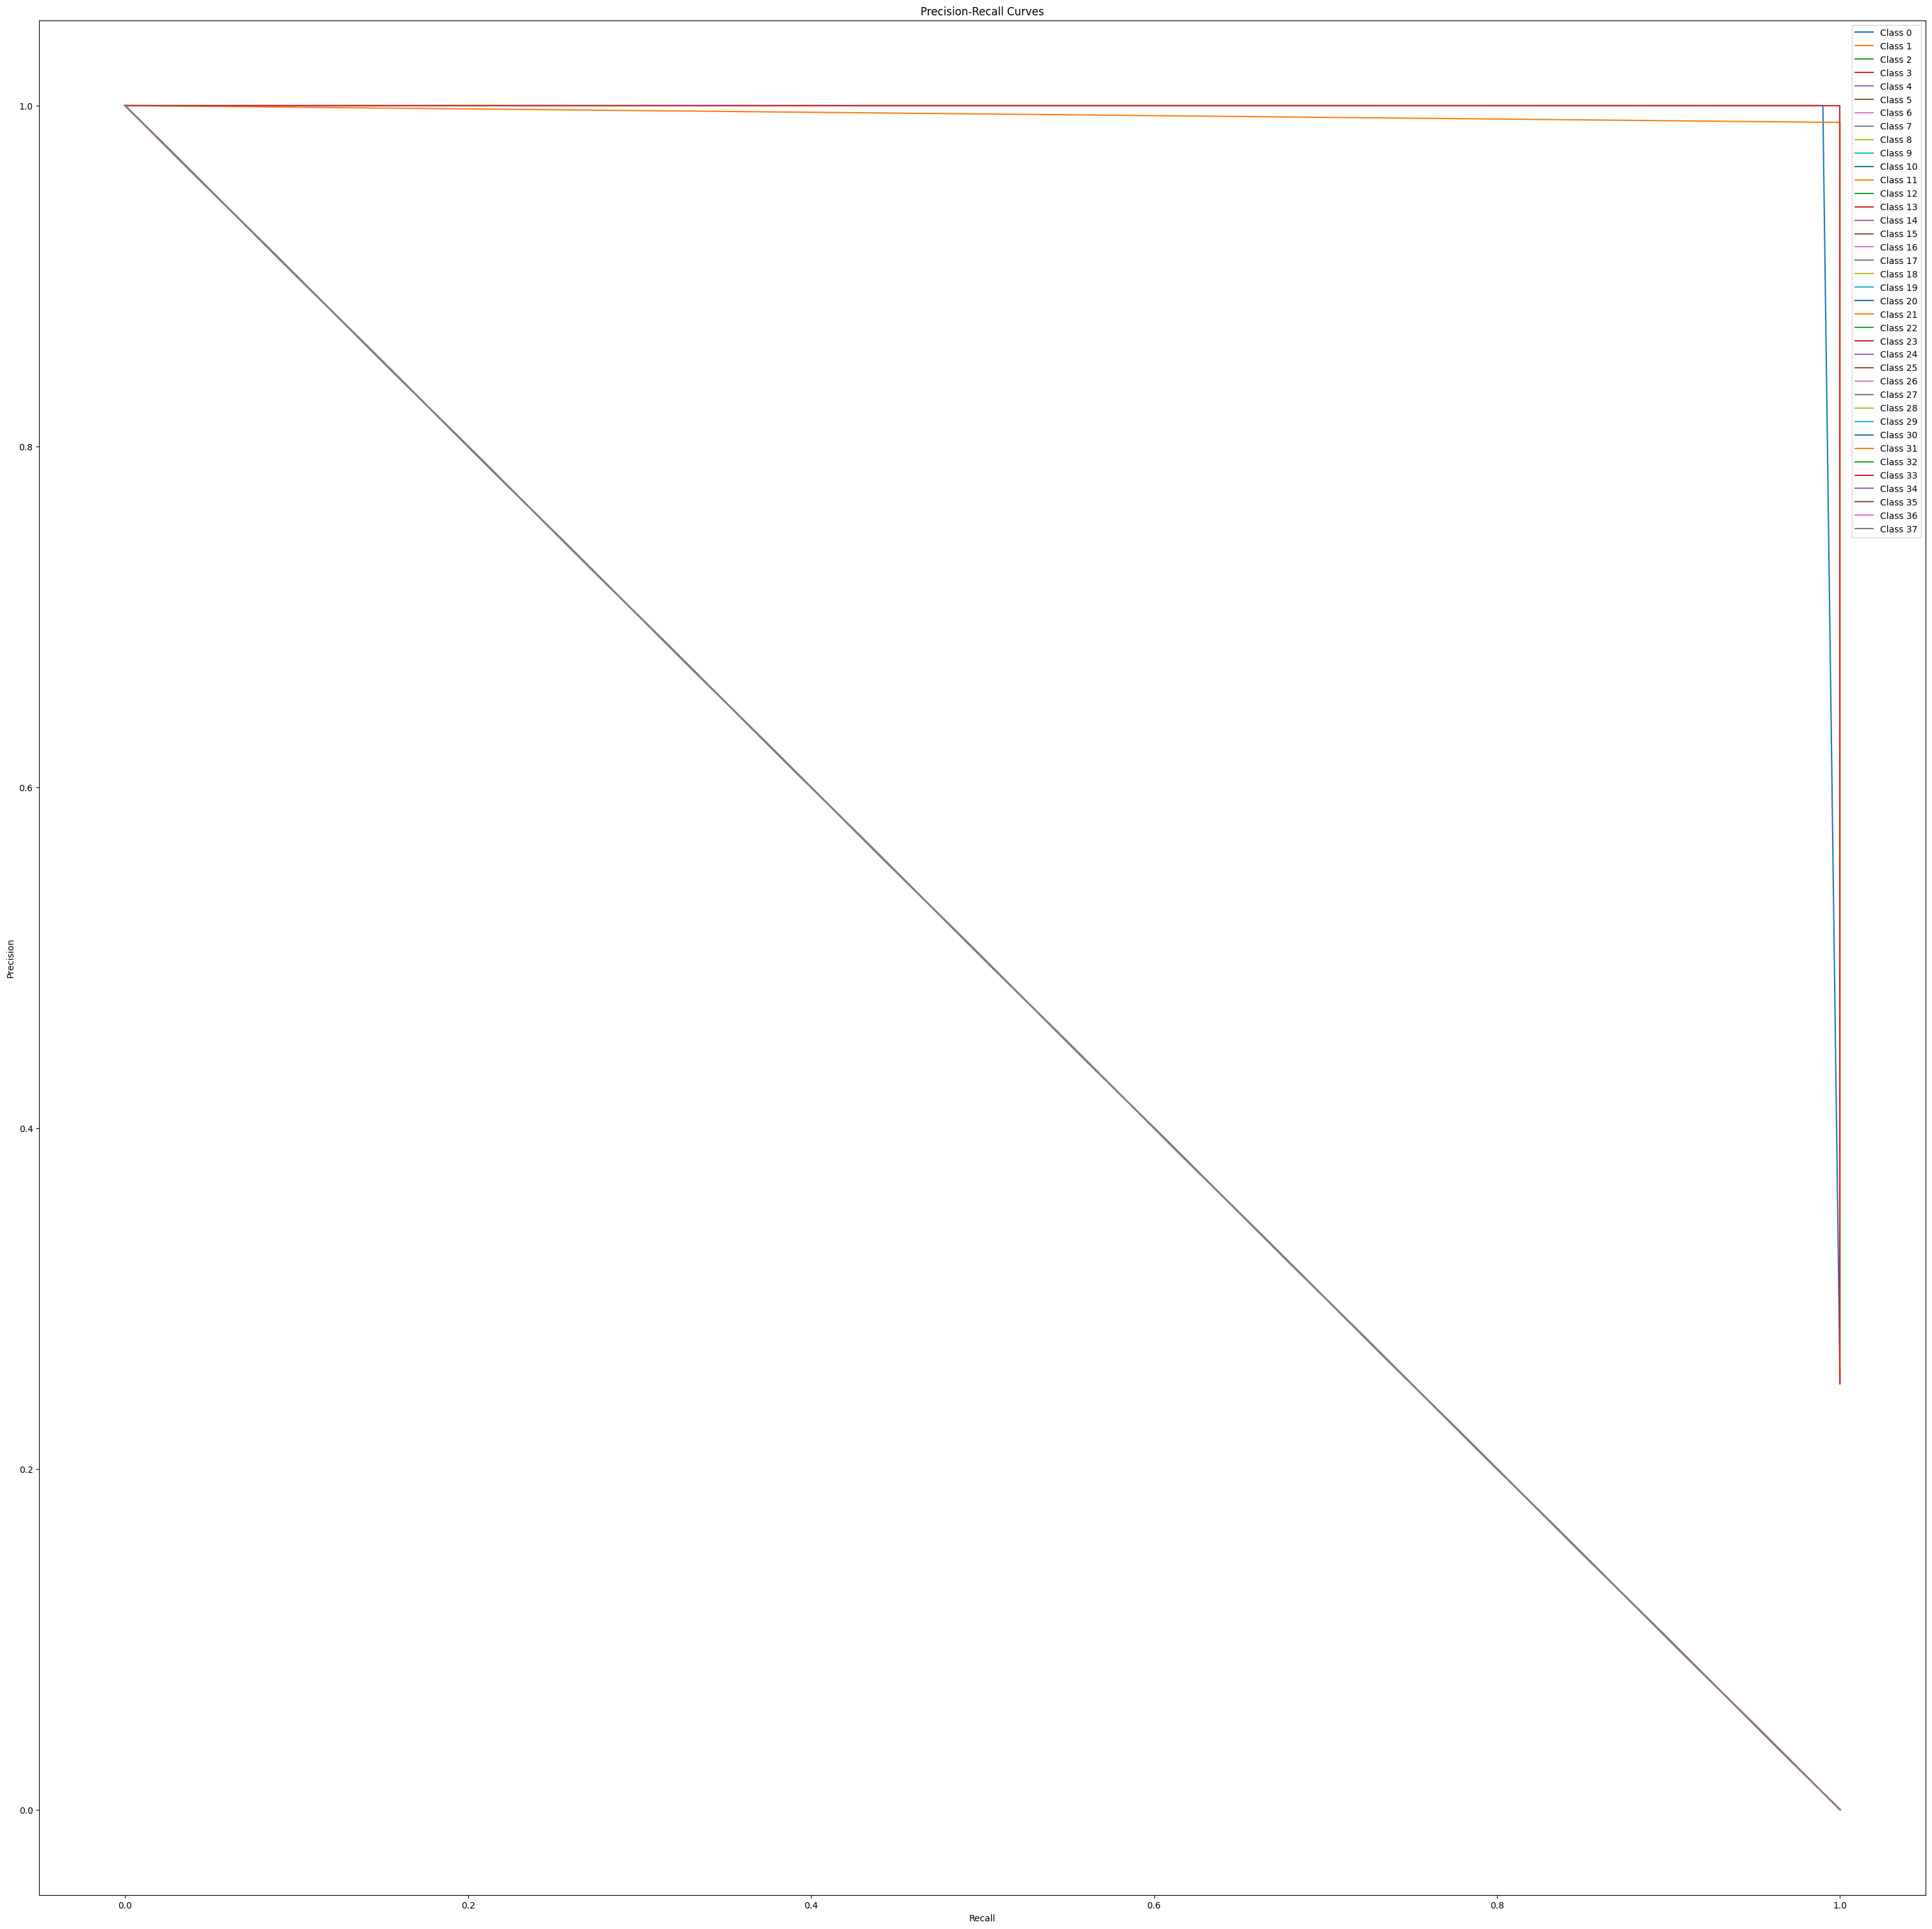

In [34]:


labels_array = np.array(labels)
predictions_array = np.array(predictions)

num_classes = 38  
labels_one_hot = label_binarize(labels_array, classes=range(num_classes))
predictions_one_hot = label_binarize(predictions_array, classes=range(num_classes))

precision = dict()
recall = dict()
plt.figure(figsize= (38,38))
for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(labels_one_hot[:, i], predictions_one_hot[:, i])
    plt.plot(recall[i], precision[i], label=f'Class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.show()

C:/Users/princ/OneDrive/Desktop/images/test\Apple___Apple_scab/test3.JPG
1/1 [==============================] - 0s 62ms/step


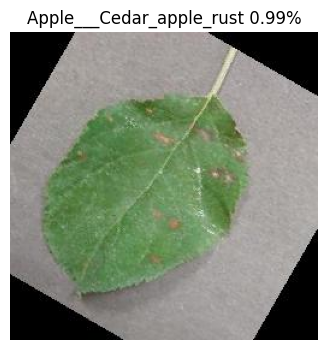

In [43]:

Li = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 
      'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 
      'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 
      'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 
      'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 
      'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch',
      'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 
      'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',
      'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']

import os
import matplotlib.pyplot as plt
from keras.preprocessing import image
import numpy as np
files = [os.path.join(test_data,p) for p in sorted(os.listdir(test_data))]
for i in range(0,1):
    image_path = files[i]
    image_path = image_path + "/test3.JPG"
    print(image_path)
    new_img =keras.utils.load_img(image_path, target_size=(256, 256))
    img = keras.utils.img_to_array(new_img)
    img = np.expand_dims(img, axis=0)
    img = img/255
    prediction = model.predict(img)
    probabilty = prediction.flatten()
    max_prob = probabilty.max()
    index=prediction.argmax(axis=-1)[0]
    class_name = Li[index]
    #ploting image with predicted class name        
    plt.figure(figsize = (4,4))
    plt.imshow(new_img)
    plt.axis('off')
    plt.title(class_name+" "+ str(max_prob)[0:4]+"%")
    plt.show()

In [44]:
model_json = model.to_json()
with open("trainedModel.json", "w") as json_file:
    json_file.write(model_json)
model.save_weights("modelWeight.h5")